No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


params0 = {'mu1': 0.49585235118865967, 'mu2': 41.39270782470703, 'mu3': 2.8384764790534973, 'gamma2_1': 0.0002221037596464157, 'gamma2_2': 1.6310324668884277, 'sigma2': 8.745217323303224e-05, 'alpha': 4.465000331401825, 'beta': Array([-0.155, -0.78 , -0.641,  0.115,  0.001, -0.546, -0.578,  0.097,
       -0.14 ,  0.71 , -0.193, -0.563,  0.316,  0.407, -0.826, -0.971,
       -0.214,  0.828,  0.243,  0.272, -0.288,  0.217,  0.776, -0.234,
       -0.921,  0.881, -0.402,  0.103, -0.802, -0.831,  0.441,  0.354,
        0.033, -0.048,  0.242,  0.131, -0.042,  0.757,  0.915,  0.287,
       -0.653, -0.089,  0.531,  0.638, -0.672, -0.251, -0.845, -0.082,
       -0.62 , -0.306], dtype=float32)}
beta^T cov = [-2.142  0.256 -2.389  1.125 -0.049  4.291 -3.213  3.464 -2.888 -0.362
 -4.864  6.942  0.051  2.057  3.052 -0.495  0.862  2.601  5.797  1.895
  0.544  2.053  4.404  0.613  1.912  0.305  6.946  5.089  4.749 -7.127
  0.476 -1.432  1.174 -5.007  3.912 -4.799  6.508 -5.201  0.017  2.944
 -2.615  

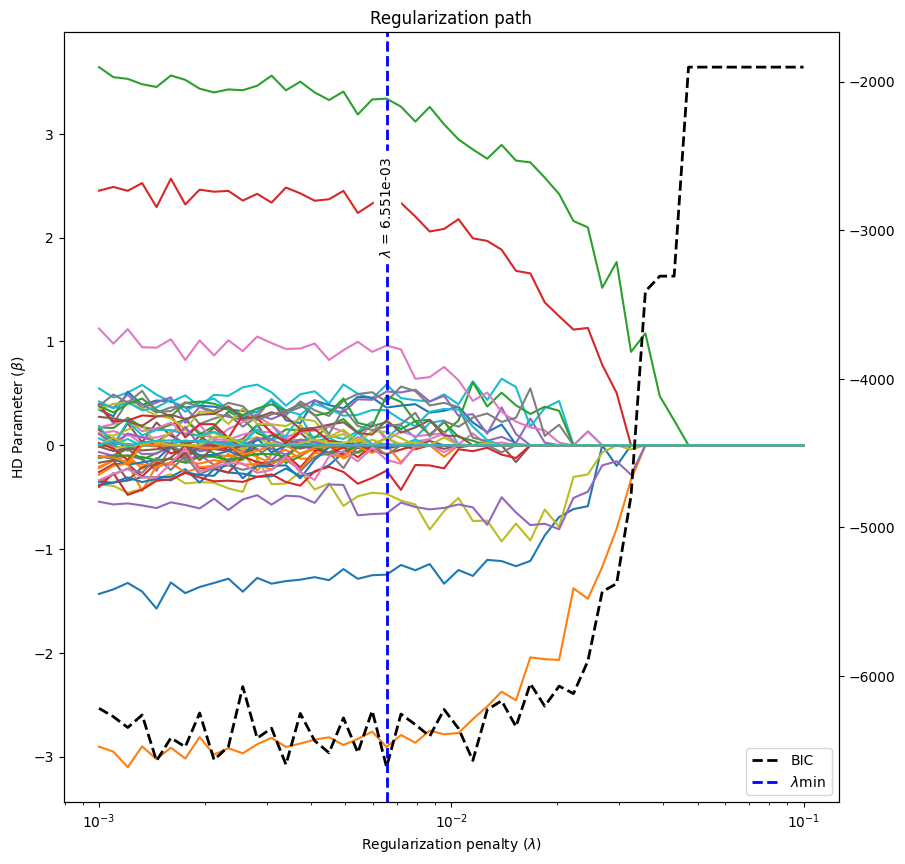

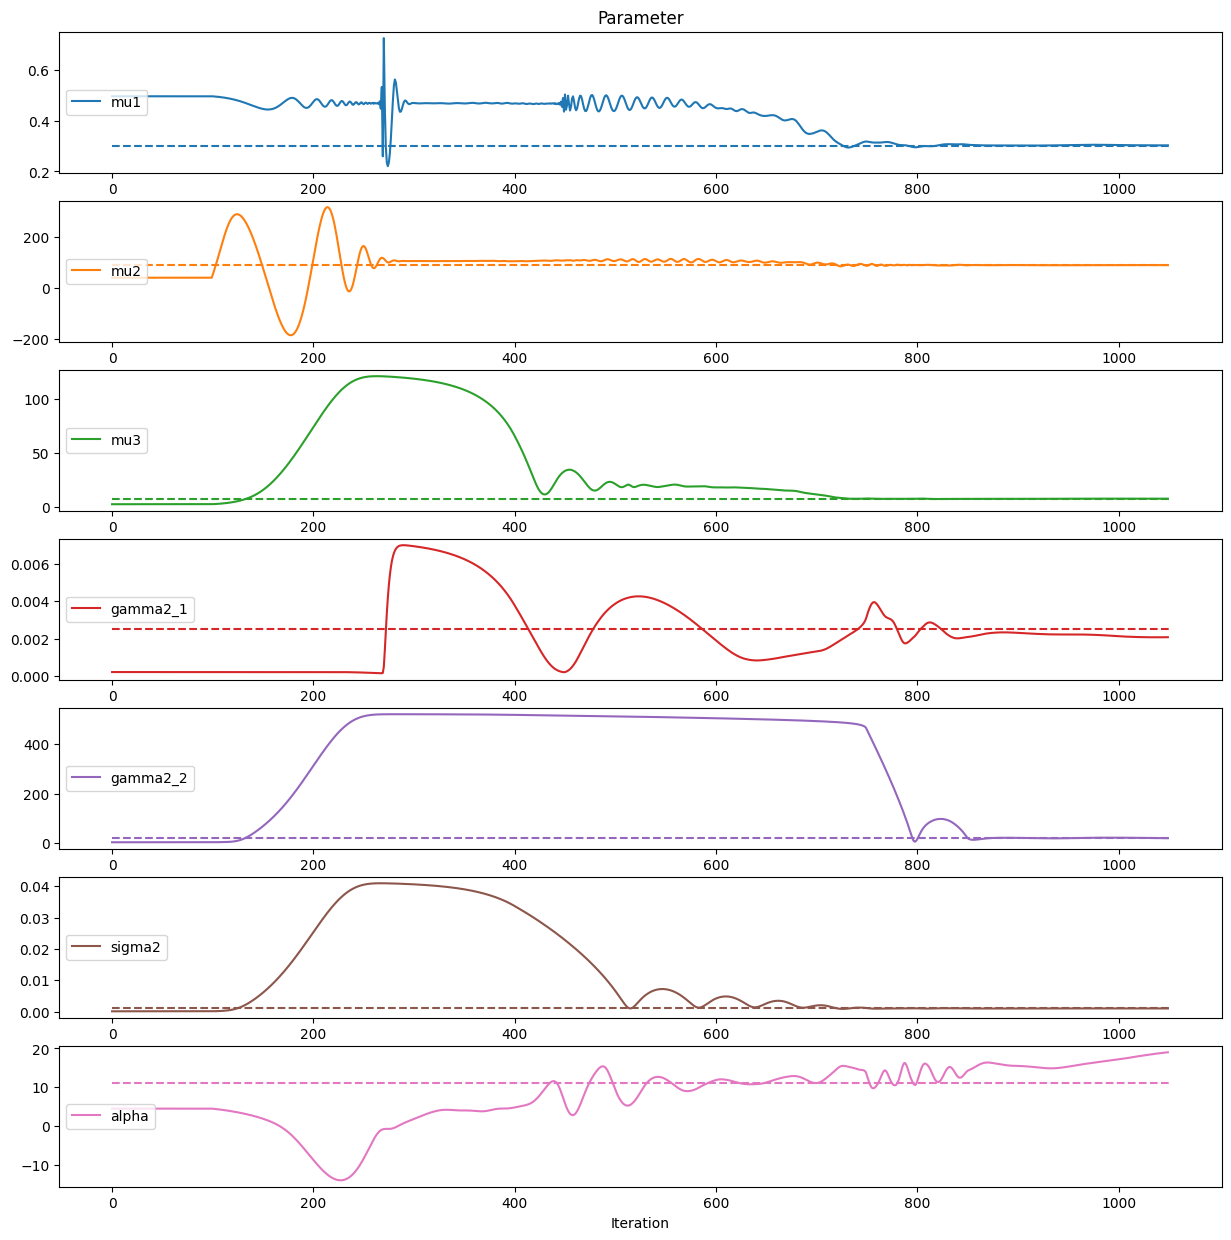

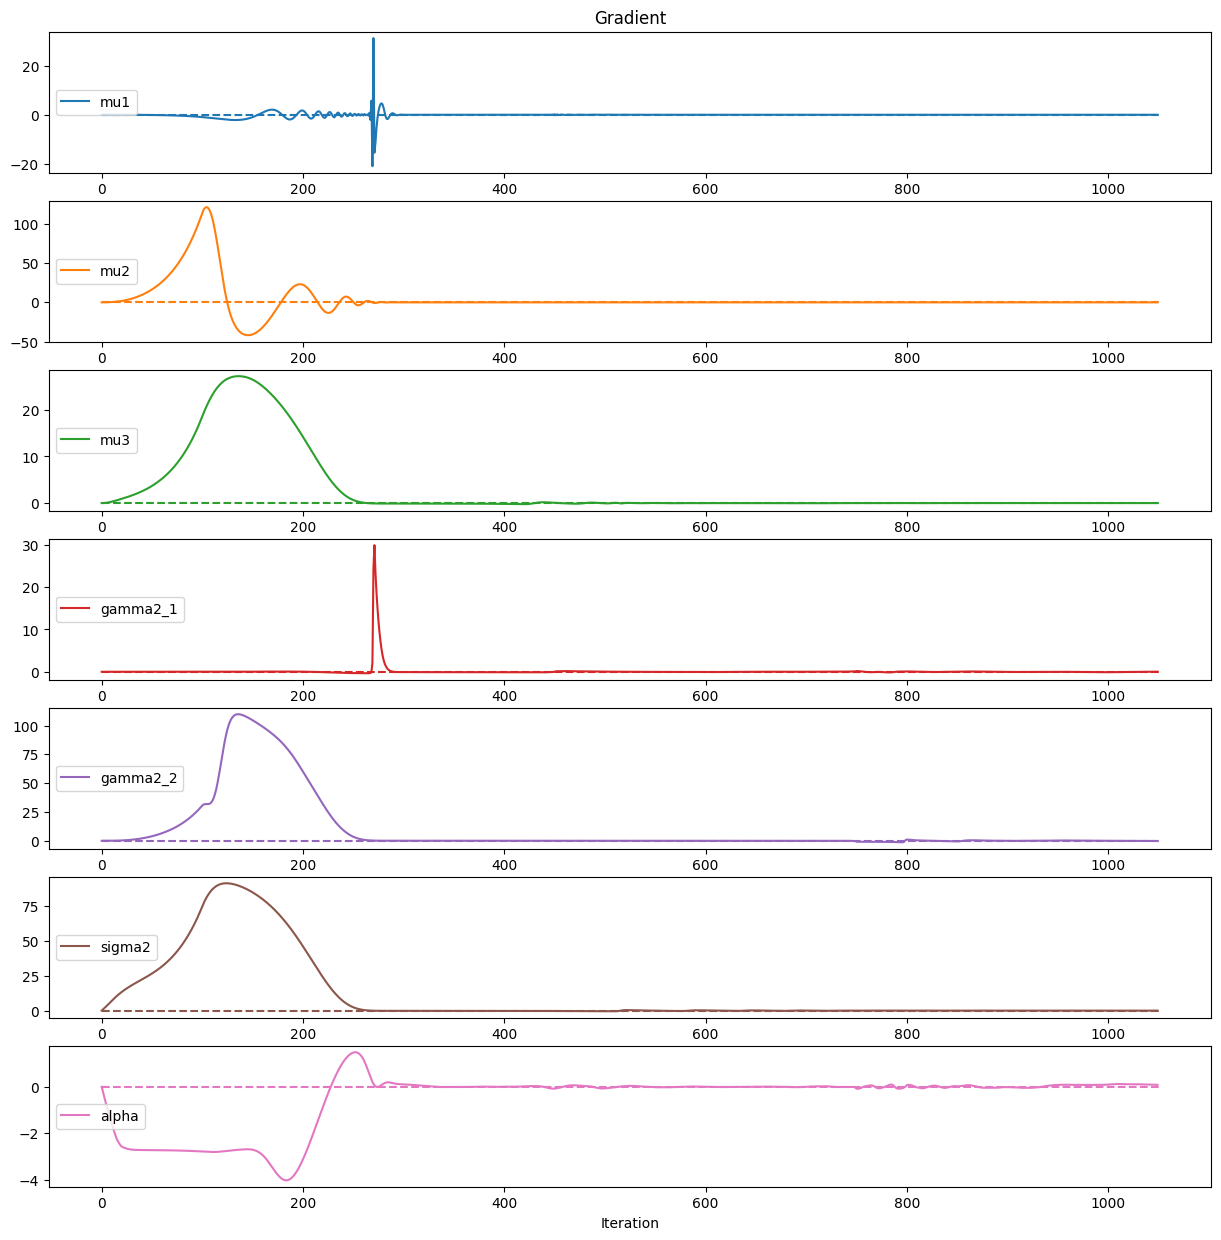

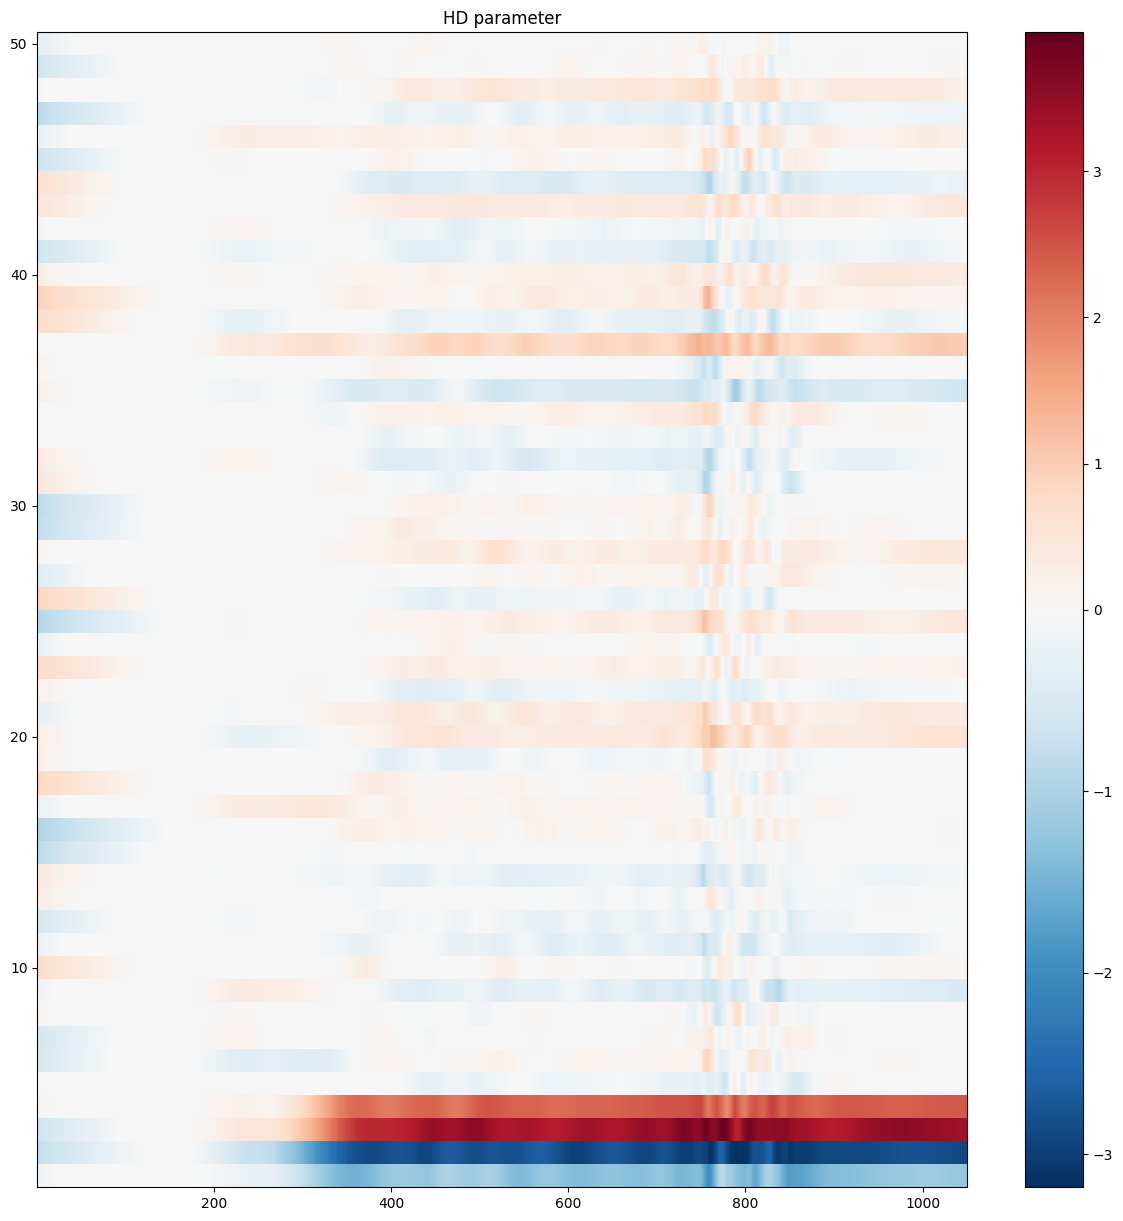

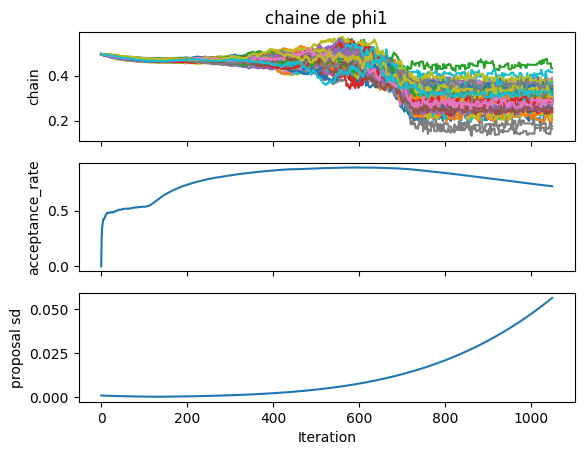

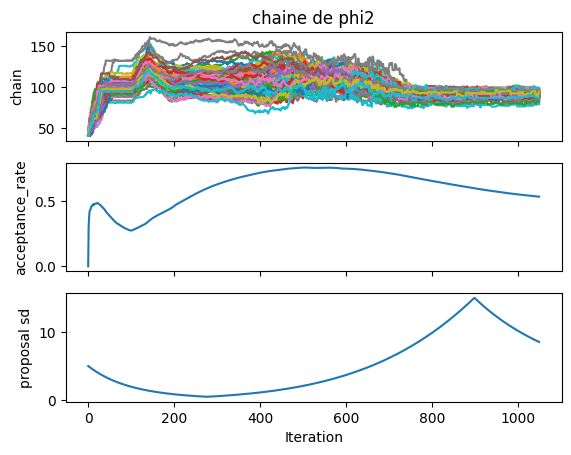

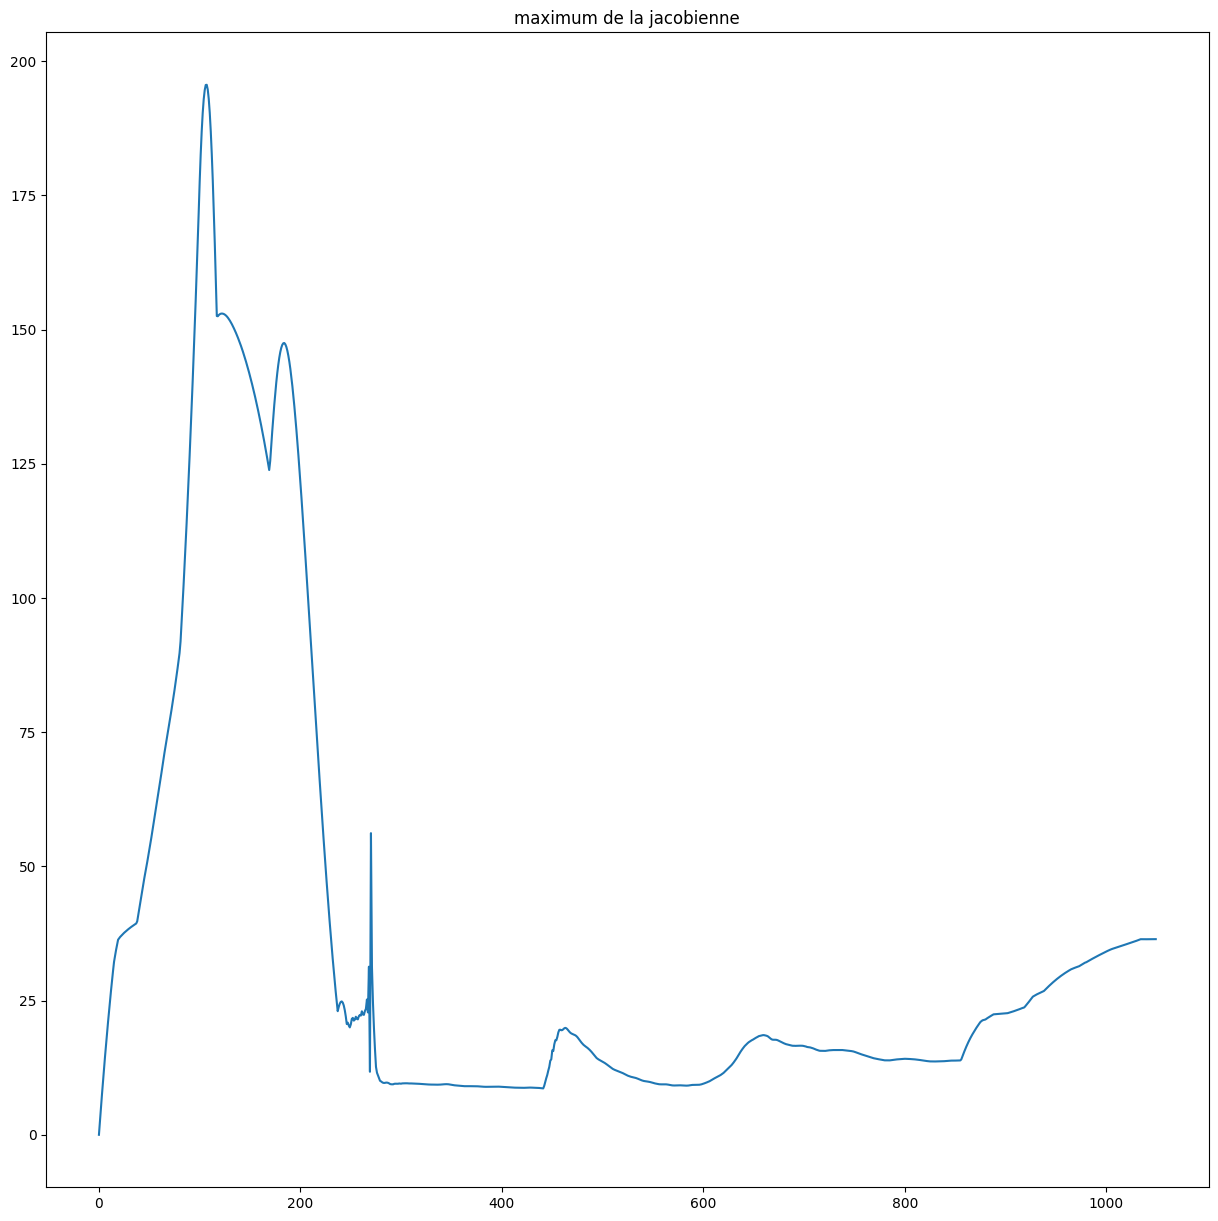

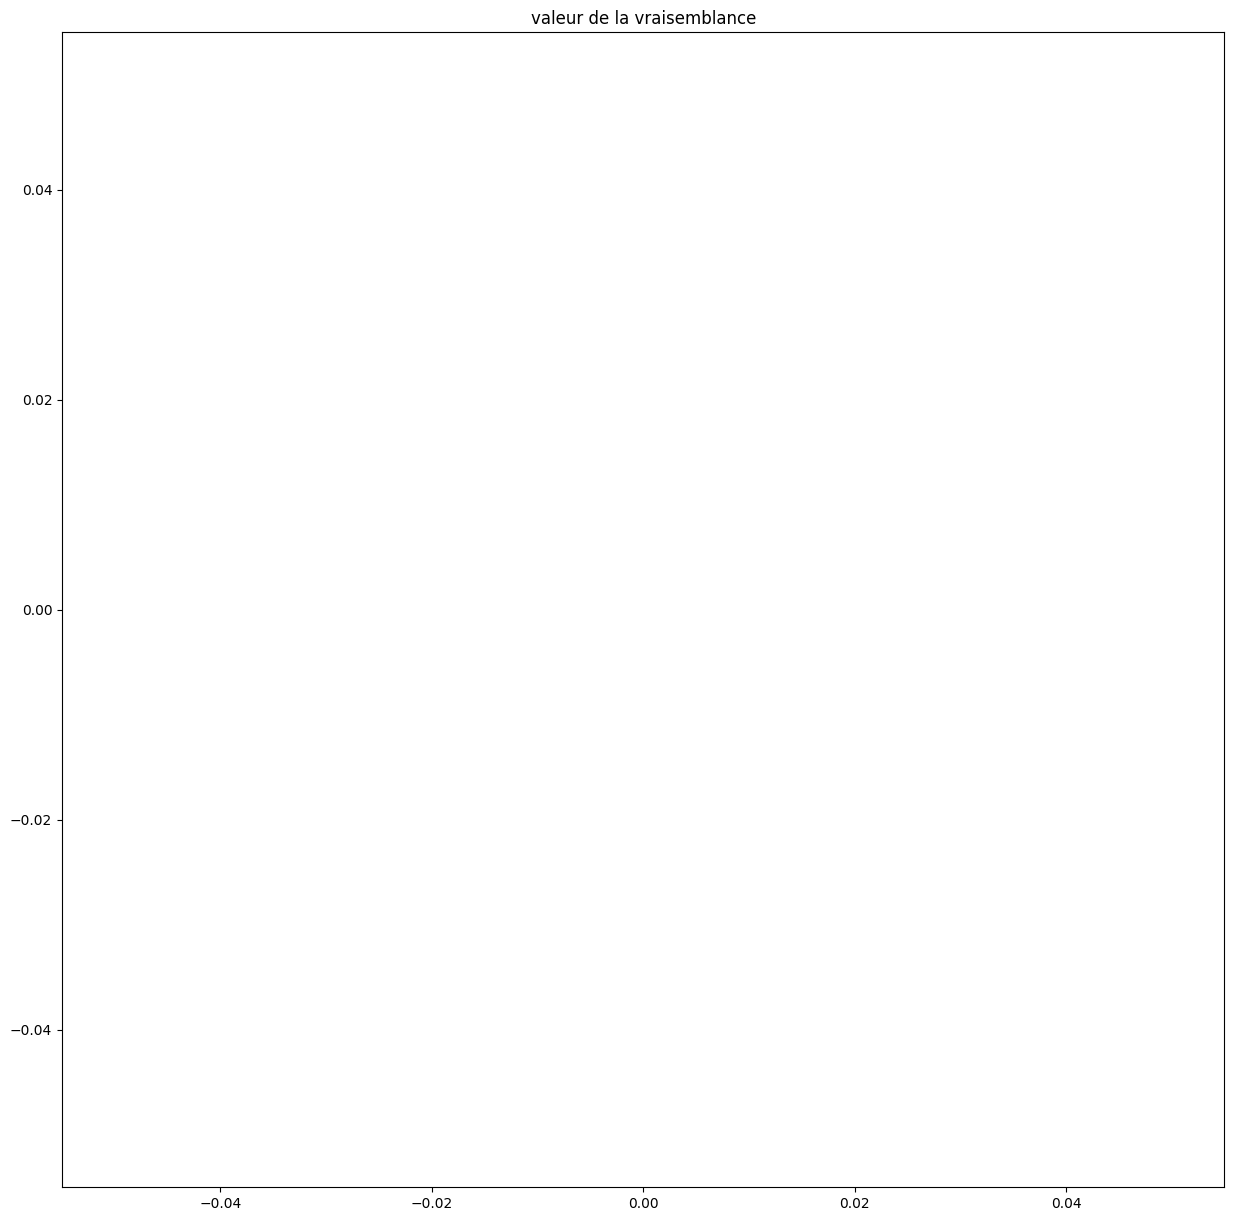

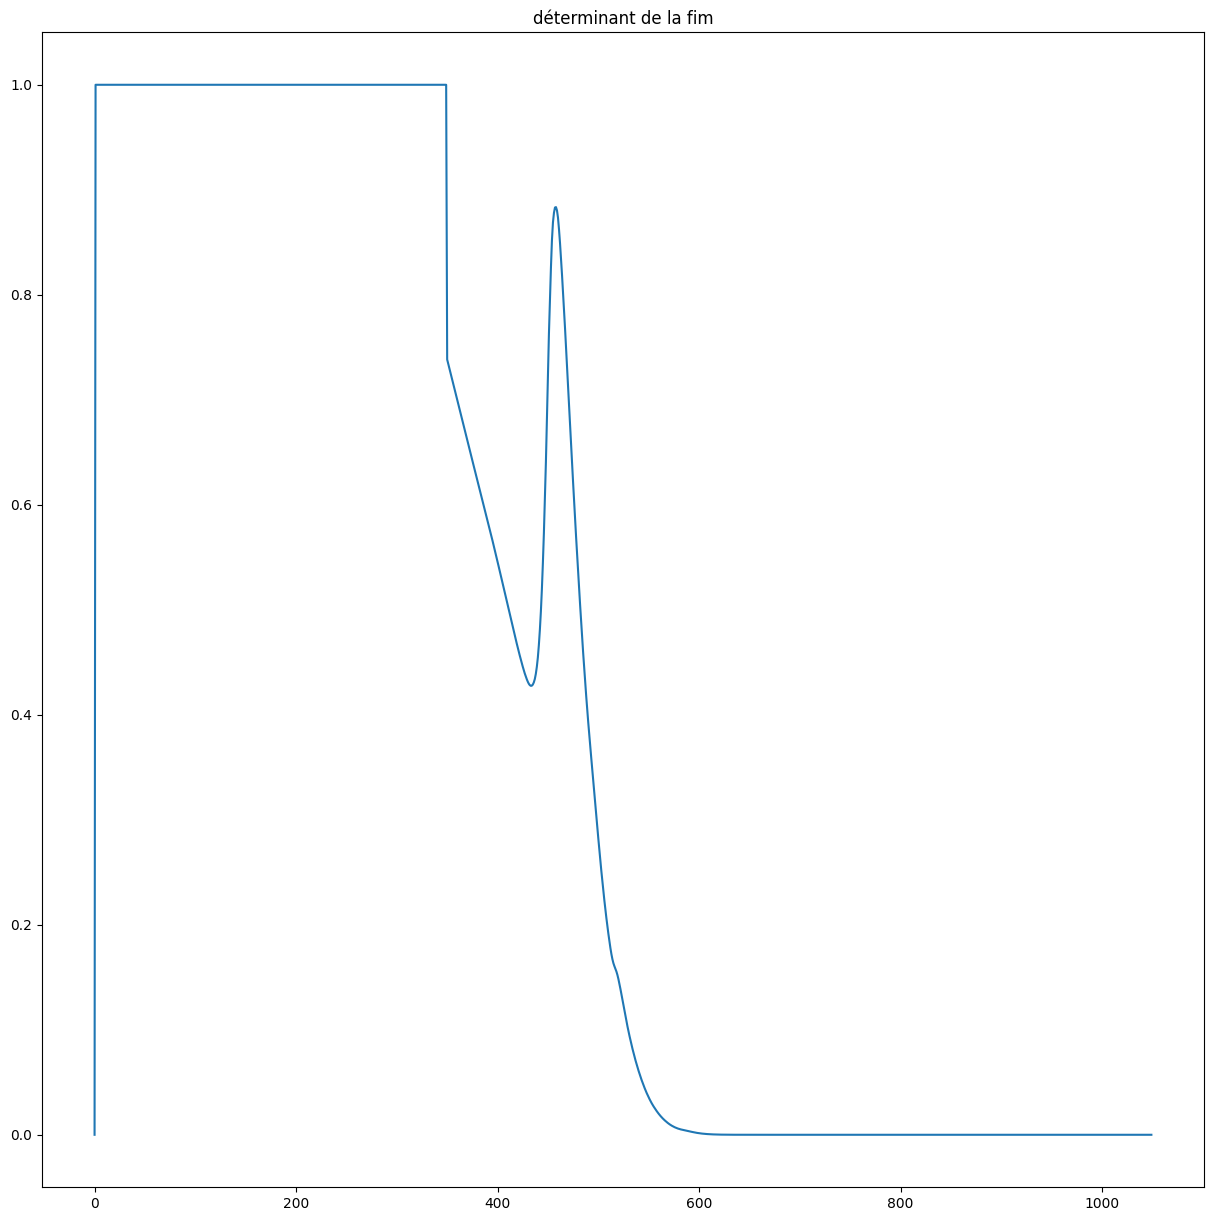

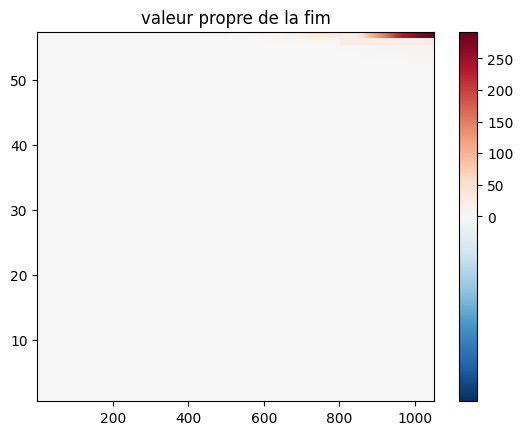

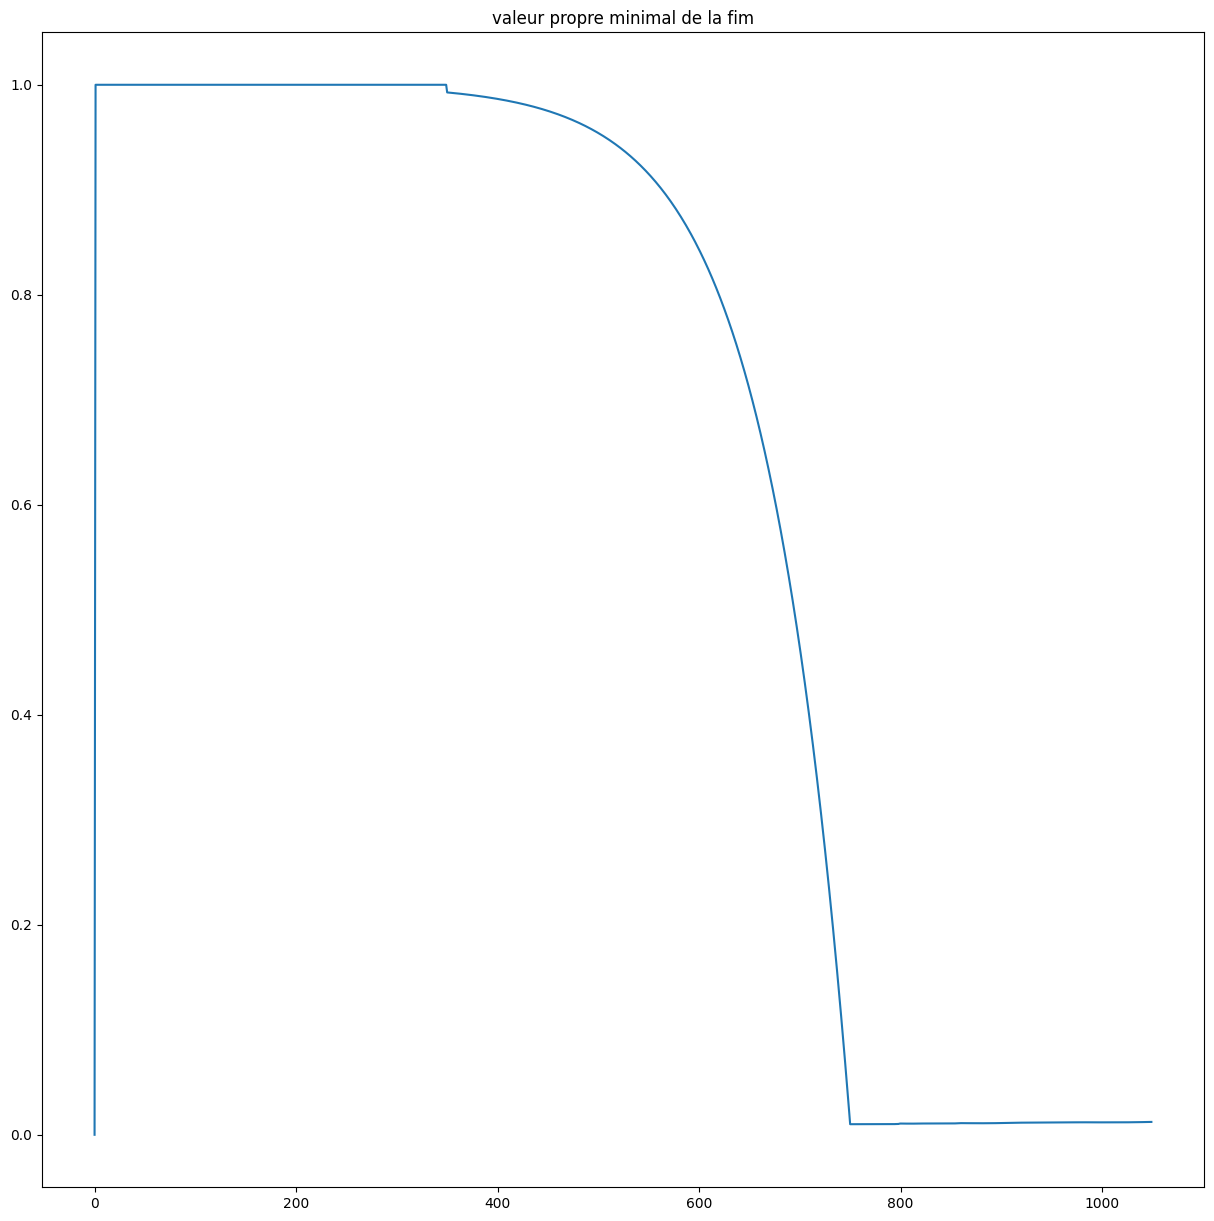

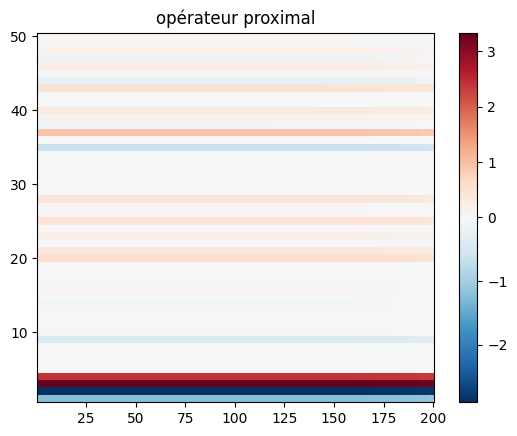

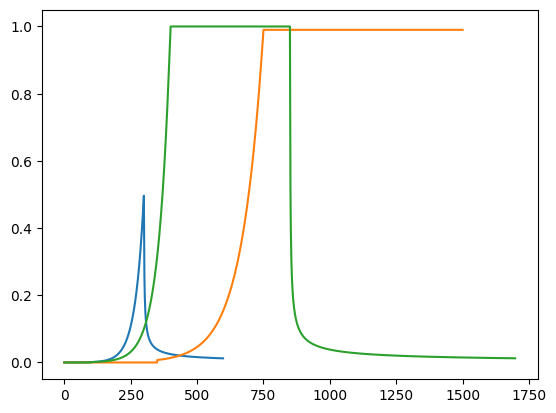

In [1]:
# Create by antoine.caillebotte@inrae.fr
from time import time
from sdg4varselect.miscellaneous import time2string

from sdg4varselect.solver import shrink_support
import numpy as np
import pandas

from one_run import (
    kwargs_run_GD,
    sample,
    estim,
    estim_solver,
    get_random_params0,
    params_star_weibull,
    N_IND,
    DIM_COV,
    params_star_stack,
)
from sdg4varselect.miscellaneous import step_message, list_bic

from sdg4varselect import jrd, jnp
import sdg4varselect.plot as sdgplt

folder = "images"


def clever_regularization_path(parameters0, path, prng_key, nrep=1, verbatim=False):
    list_res = []
    list_solver = []
    data_set, key = sample(params_star_weibull, prng_key)

    for i in range(len(path)):
        print(step_message(i, len(path)), end="\r" if not verbatim else "\n")

        kwargs_run_GD["prox_regul"] = path[i]
        kwargs_run_GD["proximal_operator"] = True
        res, solver, key = estim(data_set, parameters0, key, verbatim=verbatim)
        list_solver.append(solver)
        list_res.append(res)

        print(f"#beta = {solver.get_number_of_nonzero(p=DIM_COV)}")

        if solver.get_number_of_nonzero(p=DIM_COV) == 0:
            for k in range(len(path) - i - 1):
                print(
                    step_message(i + k, len(path)), end="\r" if not verbatim else "\n"
                )
                list_solver.append(list_solver[-1])
                list_res.append(list_res[-1])

            print(f"break at {path[i]}")
            break

    return list_solver, list_res, key


# ====================================================== #
# ================ REGULARIZATION PATH ================= #
# ====================================================== #
params0, prng_key = get_random_params0(jrd.PRNGKey(int(time())), error=0.2)
# params0["mu1"] = params_star_weibull.mu1
# params0["mu2"] = params_star_weibull.mu2
# params0["mu3"] = params_star_weibull.mu3
# params0["gamma2_1"] = params_star_weibull.gamma2_1
# params0["gamma2_2"] = params_star_weibull.gamma2_2

# params0["alpha"] = params_star_weibull.alpha

print(f"params0 = {params0}")

lbd_set = 10 ** jnp.linspace(-3, -1, num=50)  # [0.01]  #[10**0.01]  #

time_start = time()
list_solver, list_res, prng_key = clever_regularization_path(
    params0, lbd_set, prng_key, verbatim=False
)
print(f"REGULARIZATION PATH TIME: {time2string(time() - time_start)}s")
bic = list_bic(list_solver, N_IND, DIM_COV)

nrun = 2
ls, lr = [], []
for k in range(nrun - 1):
    s, r, prng_key = clever_regularization_path(params0, lbd_set, prng_key)
    ls.append(s)
    lr.append(r)
    bic += list_bic(s, N_IND, DIM_COV)

bic = bic / nrun

# # ====================================================== #
# # ====================================================== #

_, _ = sdgplt.plot_regularization_path(list_solver, lbd_set, bic, p=DIM_COV)

# # ====================================================== #
# # ====================================================== #

bic_argmin = np.argmin(bic)
print(f"regularization value selected = {lbd_set[bic_argmin]}")

solver_selection = list_solver[bic_argmin]
res_selection = list_res[bic_argmin]


# # ====================================================== #

fig, ax = sdgplt.plot_params(
    x=res_selection.theta,
    x_star=np.array(params_star_stack),
    p=DIM_COV,
    names=solver_selection.params_names,
    logscale=False,
)

_, _ = sdgplt.plot_grad(
    x=res_selection.grad_precond, p=DIM_COV, names=solver_selection.params_names
)


_, ax = sdgplt.plot_params_hd(res_selection.theta, p=DIM_COV, location="right")

for var in solver_selection.latent_variables.values():
    sdgplt.plot_mcmc(var)


# ====================================================== #


sdgplt.plot_multi_line(
    np.array([[res_selection.jac[i].max() for i in range(len(res_selection.jac))]]).T,
    0,
    title="maximum de la jacobienne",
)
sdgplt.plot_multi_line(
    np.array([res_selection.likelihood])[300:].T,
    0,
    title="valeur de la vraisemblance",
)

det_fim = np.array([[jnp.linalg.det(x) for x in res_selection.fisher_info_shrink]]).T
sdgplt.plot_multi_line(
    det_fim,
    0,
    title="déterminant de la fim",
)


vp_fim = np.array(
    [
        jnp.linalg.eigvalsh(res_selection.fisher_info_shrink[i])
        for i in range(len(res_selection.fisher_info_shrink))
    ]
)

sdgplt.ax_plot_list_of_vector(
    sdgplt.figure(),
    1,
    1,
    1,
    vp_fim,
    title="valeur propre de la fim",
    location="right",
)

sdgplt.plot_multi_line(
    np.array([vp_fim.min(axis=1)]).T,
    0,
    title="valeur propre minimal de la fim",
)


from sdg4varselect.gradient import prox

beta = solver_selection.theta_reals1d[-DIM_COV:]

lbd_set_prox = 10 ** jnp.linspace(-2, 2, num=200)
beta_prox = np.array([prox(beta, 0.001, lbd=lbd) for lbd in lbd_set_prox])


sdgplt.ax_plot_list_of_vector(
    sdgplt.figure(),
    1,
    1,
    1,
    beta_prox,
    title="opérateur proximal",
    location="right",
)


sdgplt.figure()
solver_selection.step_size.plot()
solver_selection.step_size_fisher.plot()
solver_selection.step_size_grad.plot()


# # ====================================================== #
# # ====================== INFERENCE ===================== #
# # ====================================================== #


# solver_inference, mask_select = shrink_support(solver_selection, "beta", DIM_COV)
# params0["beta"][not mask_select[-DIM_COV:].all()] = 0
# solver_inference.reset_solver()
# solver_inference.theta_reals1d = params0

# kwargs_run_GD["proximal_operator"] = False

# time_start = time()
# res_inference = estim_solver(solver_inference, verbatim=False)
# print(f"INFERENCE TIME: {time2string(time() - time_start)}")

# # # ====================================================== #
# # # ====================================================== #


# fig, ax = sdgplt.plot_params(
#     x=res_inference.theta,
#     x_star=np.array(params_star_stack),
#     p=DIM_COV,
#     names=solver_inference.params_names,
#     logscale=False,
# )

# fig, ax = sdgplt.plot_params_hd(res_inference.theta, p=DIM_COV, location="right")

In [2]:

p = DIM_COV

theta_regularization = [x.theta_reals1d[-p:] for x in list_solver]

for s in ls:
    theta_regularization += [x.theta_reals1d[-p:] for x in s]

theta_regularization /= len(ls)+1




TypeError: unsupported operand type(s) for /=: 'list' and 'int'

In [3]:

p = DIM_COV

theta_regularization = np.array([x.theta_reals1d[-p:] for x in list_solver])

for s in ls:
    theta_regularization += [x.theta_reals1d[-p:] for x in s]

theta_regularization /= len(ls)+1




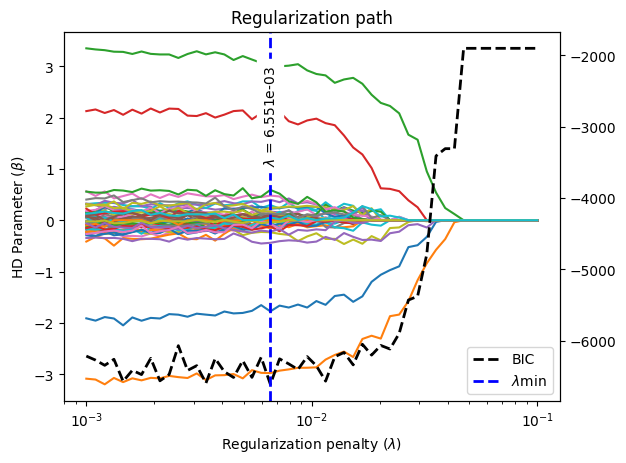

In [4]:
import matplotlib.pyplot as plt
p = DIM_COV
se_percentage=None

theta_regularization = np.array([x.theta_reals1d[-p:] for x in list_solver])

for s in ls:
    theta_regularization += [x.theta_reals1d[-p:] for x in s]

theta_regularization /= len(ls)+1



fig, ax = plt.subplots()
ax.set_title("Regularization path")
ax.set_xlabel(r"Regularization penalty ($\lambda$)")
ax.set_ylabel(r"HD Parameter ($\beta$)")
ax.set_xscale("log")
ax.plot(lbd_set, theta_regularization)

# BIC PLOT
ax_bic = ax.twinx()
ax_bic.plot(lbd_set, bic, color="k", linewidth=2, linestyle="--", label="BIC")

bic_res = {
    "bic": bic,
}

def plot_axvline(id, color, msg=""):
    lbd = lbd_set[id]

    ax_bic.axvline(
        x=lbd,
        color=color,
        linewidth=2,
        linestyle="--",
        label=r"$\lambda$" + msg,
    )
    ax_bic.text(
        lbd,
        0.8 * bic.max() + 0.2 * bic.min(),
        rf"$\lambda$ = {lbd_set[id]:.3e}",
        ha="center",
        va="center",
        rotation="vertical",
        backgroundcolor="white",
    )

# minimum value of bic
id_min = np.nanargmin(bic)
plot_axvline(id_min, color="b", msg="min")
bic_res["min"] = bic[id_min]

# bic_sub = bic_mean[1:] - bic_mean[:-1]
# id_coude = np.argmax(bic_sub > 0)
# plot_axvline(id_coude, color="g", msg=" coude")
# bic_res["coude"] = bic_mean[id_coude]

# One standard error max(min)
id_1se = (
    None
    if se_percentage is None
    else np.argmax((bic - id_min) < se_percentage * id_min)
)
bic_1se = None if id_1se is None else bic[id_1se]
if bic_1se is not None:
    plot_axvline(id_1se, color="r", msg=" 1 s.e.")
    bic_res["1se"] = bic_1se

ax_bic.legend(loc="lower right")